In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
# Data Preprocessing
# remove missing value 

df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [9]:
# Feature Engineering

df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='str')

In [10]:
# Age 
df["Age"] = 2026-df["Year_Birth"]

In [11]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_date = df["Dt_Customer"].max()

df["Customer_tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
# Spending 

df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days,Total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [15]:
# children 

df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days,Total_spending,Total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [17]:
# Education 

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate",
    "2n Cycle" : "Undergraduate",
    "graduation" : "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

# Undergrades , graduate, postgrades


In [18]:
df["Education"].value_counts()

Education
Graduation       1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [19]:
# Marital Status
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone", "Divorced": "Alone",
    "widow": "Alone", "Absured": "Alone", "YOLO":"Alone"
})



In [20]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       717
Widow        77
Absurd        2
Name: count, dtype: int64

In [21]:
# Drop A Columns

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days,Total_spending,Total_children,Living_With
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [22]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]


cols_to_drop = cols + spending

df_cleaned = df.drop(columns=cols_to_drop)

In [23]:
df_cleaned.shape

(2240, 15)

In [24]:
df.shape

(2240, 27)

In [25]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days,Total_spending,Total_children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


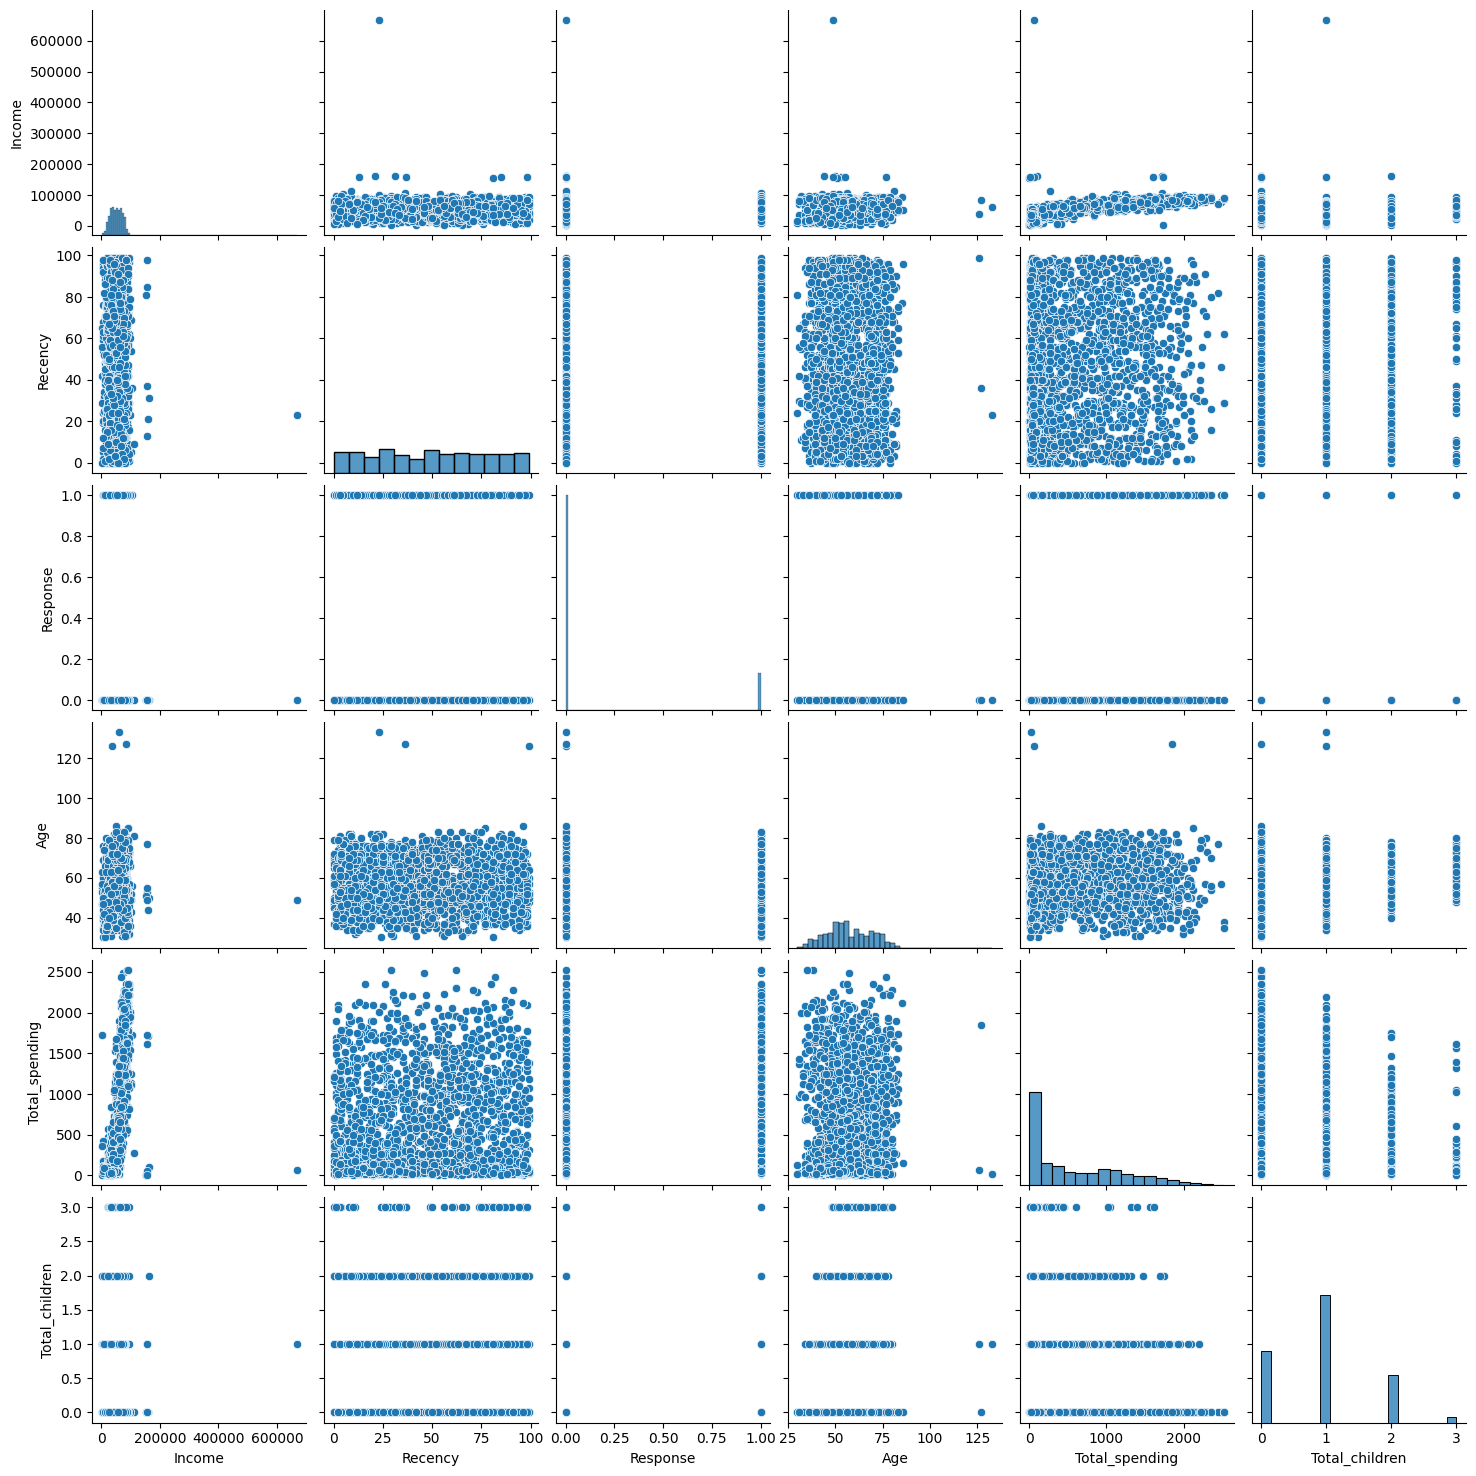

In [26]:
# Outliers

cols = ["Income", "Recency", "Response", "Age", "Total_spending", "Total_children"]

# relative plot of some features 
sns.pairplot(df_cleaned[cols])

In [27]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_Days', 'Total_spending',
       'Total_children', 'Living_With'],
      dtype='str')

In [28]:
# Remove The OutLiers

print("Data size with outliers", len(df_cleaned))

df_cleaned = df_cleaned[df_cleaned["Age"] < 90]
df_cleaned = df_cleaned[df_cleaned["Income"] < 600_000]


Data size with outliers 2240


In [29]:
# Heat Map

corr = df_cleaned.corr(numeric_only=True)

<Axes: >

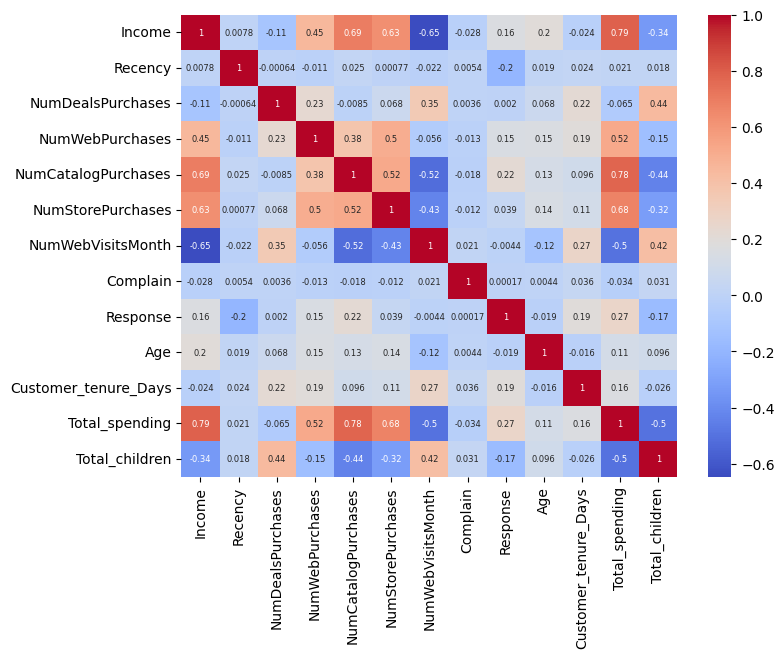

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
    
)

In [31]:
# Encoding 

from sklearn.preprocessing import OneHotEncoder

In [32]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [33]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [34]:
enc_df.head()

,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_With_Absurd,Living_With_Alone,Living_With_Partner,Living_With_Widow
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [35]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [36]:
df_encoded

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days,Total_spending,Total_children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_With_Absurd,Living_With_Alone,Living_With_Partner,Living_With_Widow
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Text(0.5, 0.92, '3d projection')

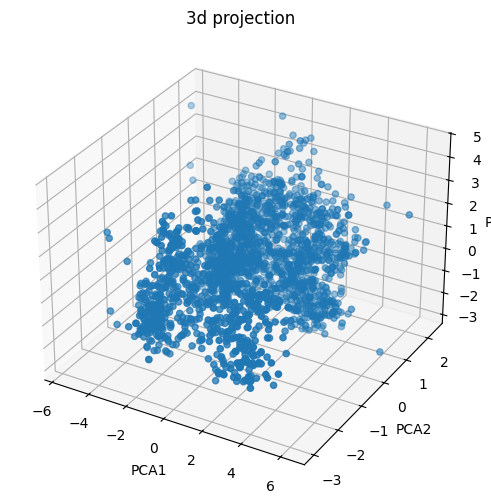

In [37]:
from sklearn.preprocessing import StandardScaler

X = df_encoded



scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


X_scaled.shape




from sklearn.decomposition import PCA


pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)



pca.explained_variance_ratio_






# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [38]:
# Choose K Value

# 1st Elbow method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [39]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [40]:
print("Best K value is", optimal_k)

Best K value is 5


Text(0, 0.5, 'WCSS')

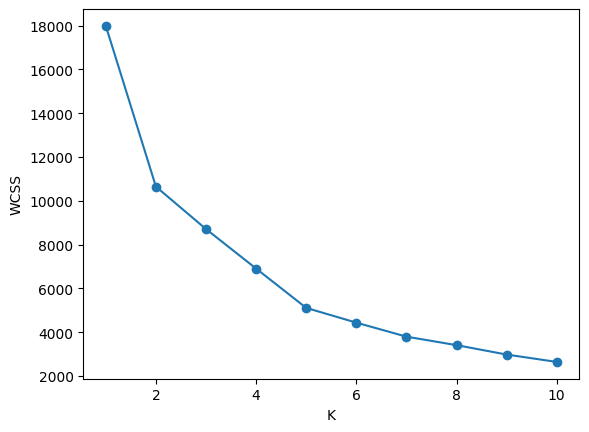

In [41]:
# Plot

plt.plot(range(1, 11), wcss, marker="o")

plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhoutte score ')

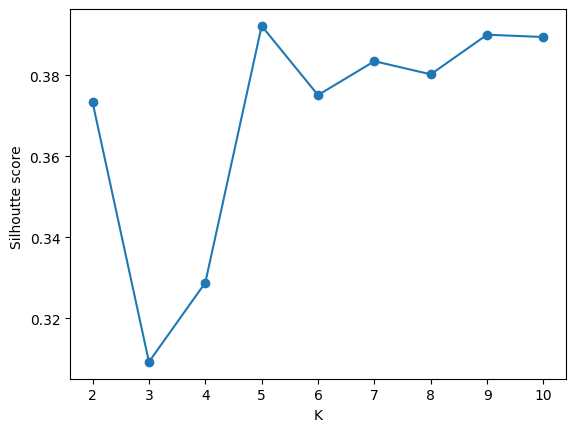

In [42]:
# For Silhoute Score 
from sklearn.metrics import silhouette_score 

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    scores.append(score)


    # plot

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhoutte score ")

Text(0, 0.5, 'ss')

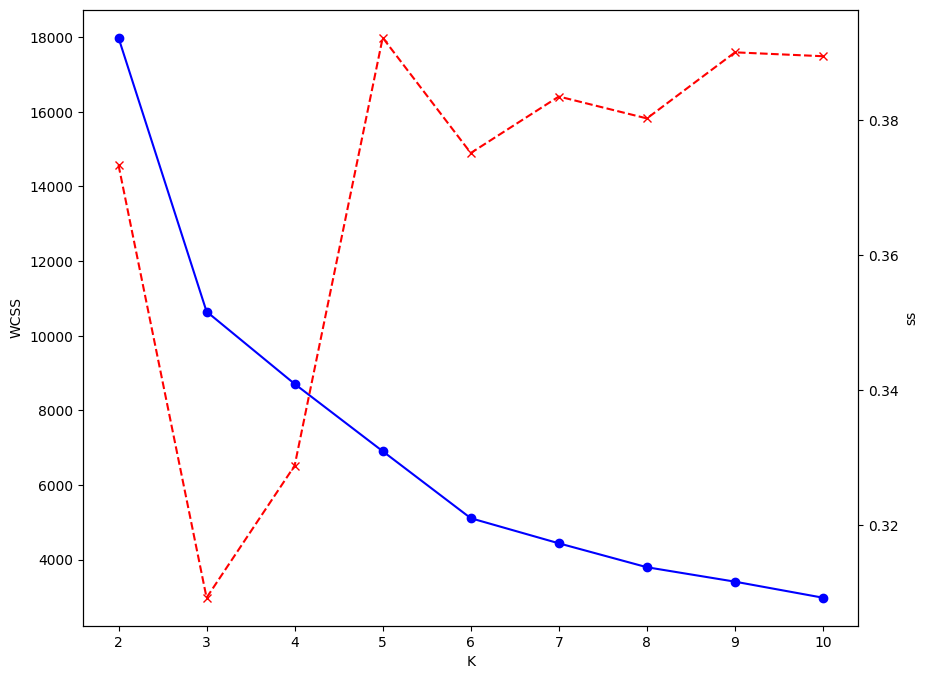

In [43]:
#Combined Plot

k_range = range(2, 11)

fig, ax1= plt.subplots(figsize=(10, 8))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")



ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")

ax2.set_ylabel("ss")

In [44]:
# Apply Clustering Algorithm 

# kmeans 

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

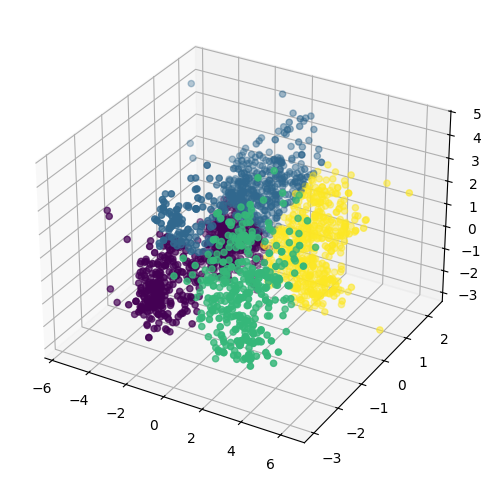

In [45]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [46]:
## Aglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

In [47]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")

labels_agg =agg_clf.fit_predict(X_pca)

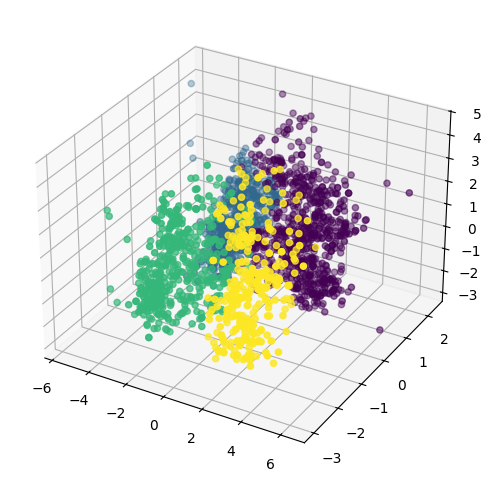

In [48]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

# Characterization of Cluster 


In [64]:


X["cluster"] = labels_agg

In [65]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,...,Total_spending,Total_children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_With_Absurd,Living_With_Alone,Living_With_Partner,Living_With_Widow,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,...,1617,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,...,27,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,...,776,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,...,53,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
4,58293.0,94,5,5,3,6,5,0,0,45,...,422,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1


<Axes: xlabel='cluster', ylabel='count'>

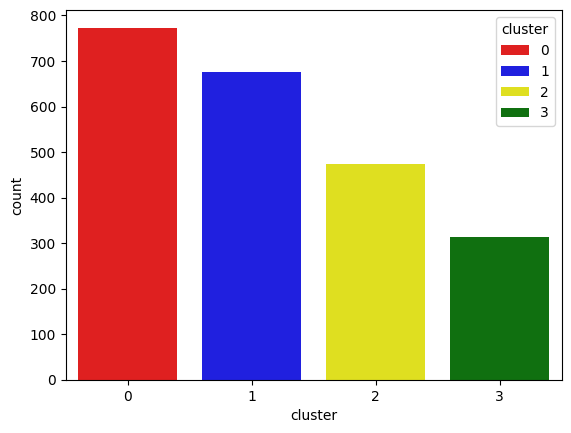

In [66]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

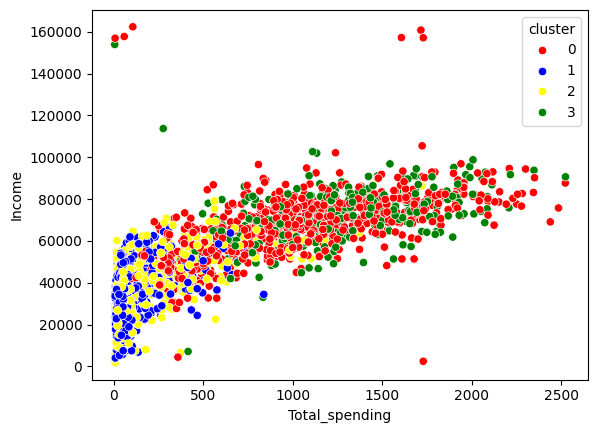

In [68]:
## Income and spending pattern

sns.scatterplot(x=X["Total_spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [67]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        66818.851876  48.723157           2.469599         5.615783   
1        34689.391272  49.539941           2.233728         2.306213   
2        39257.399577  47.763214           2.570825         3.012685   
3        71644.248408  51.210191           1.802548         5.780255   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.467012           7.957309           4.191462  0.007762   
1                   0.536982           3.319527           6.621302  0.010355   
2                   1.012685           4.012685           6.473573  0.010571   
3                   5.286624           8.490446           3.550955  0.006369   

         Response        Age  Customer_tenure_Days  Total_spending  \
cluster         